In [3]:
import geopandas as gpd

try:
    # Read GeoJSON file into a GeoDataFrame
    gdf = gpd.read_file('../results/dhm.geojson')
    
    # Verify the data was loaded correctly
    print(f"Loaded {len(gdf)} features")
    print(f"Columns: {gdf.columns}")
    
except FileNotFoundError:
    print("Error: dhm.geojson file not found")
except Exception as e:
    print(f"Error loading GeoJSON: {e}")

Loaded 465 features
Columns: Index(['id', 'type', 'existence', 'rect', 'eqi', 'sc', 'geometry'], dtype='object')


In [4]:
gdf.head()

,id,type,existence,rect,eqi,sc,geometry
0,0,2,True,NaN,NaN,NaN,"LINESTRING (0.00000 0.00000, 432.00000 0.00000)"
1,1,2,True,NaN,NaN,NaN,"LINESTRING (432.00000 0.00000, 1224.00000 0.00..."
2,2,2,True,NaN,NaN,NaN,"LINESTRING (1224.00000 0.00000, 1867.00000 0.0..."
3,3,2,False,NaN,NaN,NaN,"LINESTRING (0.00000 2768.00000, 0.00000 2596.4..."
4,4,2,True,NaN,NaN,NaN,"LINESTRING (0.00000 2414.00000, 0.00000 1932.0..."


In [1]:
import sys
sys.path.append('/home/lxh/dev/DRL-urban-planning')
from urban_planning.envs import CityEnv
from urban_planning.envs import city_config
from urban_planning.utils.config import Config
id = 'dhm'
seed = 111
temp = False
cfg = Config(id, seed, temp, root_dir="/home/lxh/dev/DRL-urban-planning")
env = CityEnv(cfg)

/home/lxh/anaconda3/envs/urban3/lib/python3.9/site-packages/geopandas/_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(
/home/lxh/anaconda3/envs/urban3/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Carbon emissions:
None


In [12]:
import geopandas as gpd
import pickle


# Read GeoJSON file into a GeoDataFrame
d=pickle.load(open('/home/lxh/dev/drl_urban_planning/dhm/111/plan/plan.p', 'rb'))
print(d)
    


[{'road_network': -1.0, 'life_circle': 0.6567878366871375, 'greenness': 0.4095737512214715, 'concept': -1.0, 'life_circle_info': {'life_circle_15min': 0.9103448275862068, 'life_circle_10min': 0.6413793103448276, 'life_circle_5min': 0.3310344827586207, 'life_circle_10min_area': 0.5280284352771545, 'decentralization_reward': 0.3081705268461961, 'utility': 0.2966413114694568, 'shopping': 0.5172413793103449, 'working': 0.41379310344827586, 'education': 0.7586206896551724, 'medical care': 0.7586206896551724, 'entertainment': 0.7586206896551724}, 'concept_info': {}, 'land_use_reward': 3.0367250979700215, 'gdf':      type  existence                                           geometry  \
id                                                                        
0       2       True            LINESTRING (0.000 0.000, 432.000 0.000)   
1       2       True         LINESTRING (432.000 0.000, 1224.000 0.000)   
2       2       True        LINESTRING (1224.000 0.000, 1867.000 0.000)   
3       2   

In [14]:
gdf = d[0]['gdf']

# Verify the data was loaded correctly
print(f"Loaded {len(gdf)} features")
print(f"Columns: {gdf.columns}")

Loaded 415 features
Columns: Index(['type', 'existence', 'geometry', 'rect', 'eqi', 'sc'], dtype='object')


In [ ]:
env.load_plan(gdf)
#env.score_plan()

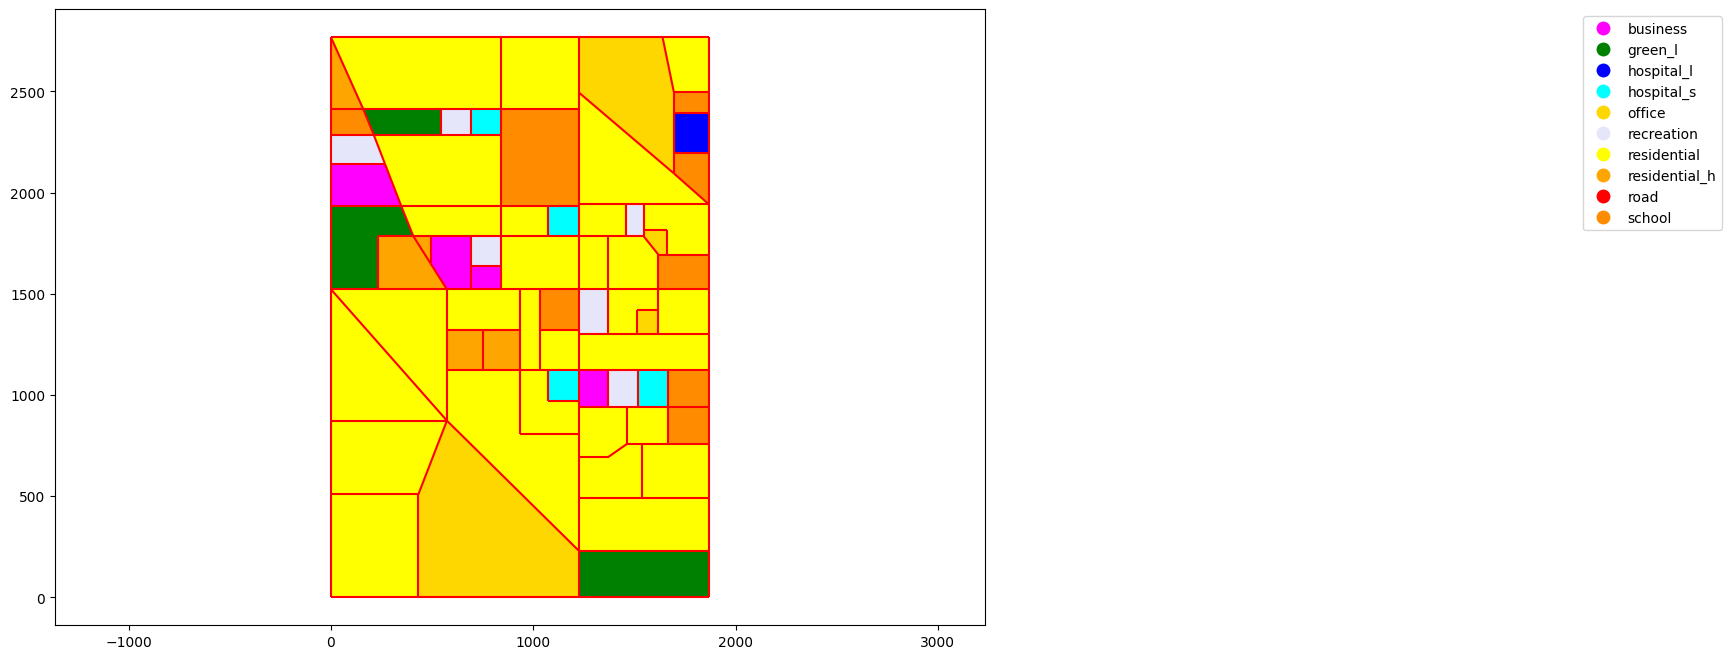

In [19]:
env.visualize()

In [1]:
import geopandas as gpd
from shapely.geometry import Polygon

# 创建示例数据，使用自定义坐标
data = [
    {"type": "Feature", "properties": {"id": 1, "type": "residential"}, "geometry": {"type": "Polygon", "coordinates": [[[0, 0], [4, 0], [4, 3], [0, 3], [0, 0]]]}},
    {"type": "Feature", "properties": {"id": 2, "type": "business"}, "geometry": {"type": "Polygon", "coordinates": [[[5, 5], [10, 5], [10, 8], [5, 8], [5, 5]]]}}
]

# 将数据转换为GeoDataFrame
gdf = gpd.GeoDataFrame.from_features(data)

#gdf.set_crs(epsg=4326, inplace=True)

# 打印GeoDataFrame
print(gdf)

# 计算每个地块的面积
gdf['area'] = gdf.geometry.area

# 打印带有面积的GeoDataFrame
print(gdf[['id', 'type', 'area']])

: 